# Claim Approval Prediction (Machine Learning)


## Import Libraries


In [32]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## Load Dataset

In [33]:

df = pd.read_csv("../RawData/Enhanced Health Insurance Claims Dataset.csv")

print(df.shape)

df.head()

(4500, 17)


,ClaimID,PatientID,ProviderID,ClaimAmount,ClaimDate,DiagnosisCode,ProcedureCode,PatientAge,PatientGender,ProviderSpecialty,ClaimStatus,PatientIncome,PatientMaritalStatus,PatientEmploymentStatus,ProviderLocation,ClaimType,ClaimSubmissionMethod
0,10944daf-f7d5-4e1d-8216-72ffa609fe41,8552381d-7960-4f64-b190-b20b8ada00a1,4a4cb19c-4863-41cf-84b0-c2b21aace988,3807.95,07-06-2024,yy006,hd662,16,M,Cardiology,Pending,90279.43,Married,Retired,Jameshaven,Routine,Paper
1,fcbebb25-fc24-4c0f-a966-749edcf83fb1,327f43ad-e3bd-4473-a9ed-46483a0a156f,422e02dd-c1fd-43dd-8af4-0c3523f997b1,9512.07,30-05-2023,tD052,mH831,27,M,Pediatrics,Approved,130448.02,Single,Student,Beltrantown,Routine,Online
2,9e9983e7-9ea7-45f5-84d8-ce49ccd8a4a1,6f3acdf7-73aa-4afa-9c2e-b25b27bdb5b0,f7733b3f-0980-47b5-a7a0-ee390869355b,7346.74,27-09-2022,zx832,dg637,40,F,Cardiology,Pending,82417.54,Divorced,Employed,West Charlesport,Emergency,Online
3,a06273ed-44bb-452b-bbad-8618de080494,5d58e183-701e-406c-a8c6-5b73cac5e912,f7a04581-de96-44ee-b773-8adac02baa59,6026.72,25-06-2023,kr421,kG326,65,M,Neurology,Pending,68516.96,Widowed,Student,West Aprilhaven,Routine,Phone
4,f702a717-254b-4cff-a0c7-8395db2f6616,8a8ebdf6-3af0-4f14-82f3-37b937c3d270,b80b9e77-97f0-47d7-b561-19f9658a7bdf,1644.58,24-07-2023,LZ261,cx805,24,M,General Practice,Pending,84122.17,Married,Student,Lake Michele,Inpatient,Phone


## Understand Data (EDA)

In [34]:
df.info()
print()
print(df.describe().astype(int))
print()
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4500 entries, 0 to 4499
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ClaimID                  4500 non-null   object 
 1   PatientID                4500 non-null   object 
 2   ProviderID               4500 non-null   object 
 3   ClaimAmount              4500 non-null   float64
 4   ClaimDate                4500 non-null   object 
 5   DiagnosisCode            4500 non-null   object 
 6   ProcedureCode            4500 non-null   object 
 7   PatientAge               4500 non-null   int64  
 8   PatientGender            4500 non-null   object 
 9   ProviderSpecialty        4500 non-null   object 
 10  ClaimStatus              4500 non-null   object 
 11  PatientIncome            4500 non-null   float64
 12  PatientMaritalStatus     4500 non-null   object 
 13  PatientEmploymentStatus  4500 non-null   object 
 14  ProviderLocation        

##  Data Cleaning
Step 4 — Data Cleaning

In [35]:
# Drop unnecessary ID columns

df.drop(["ClaimID", "PatientID", "ProviderID"], axis=1, inplace=True)
df.head()

,ClaimAmount,ClaimDate,DiagnosisCode,ProcedureCode,PatientAge,PatientGender,ProviderSpecialty,ClaimStatus,PatientIncome,PatientMaritalStatus,PatientEmploymentStatus,ProviderLocation,ClaimType,ClaimSubmissionMethod
0,3807.95,07-06-2024,yy006,hd662,16,M,Cardiology,Pending,90279.43,Married,Retired,Jameshaven,Routine,Paper
1,9512.07,30-05-2023,tD052,mH831,27,M,Pediatrics,Approved,130448.02,Single,Student,Beltrantown,Routine,Online
2,7346.74,27-09-2022,zx832,dg637,40,F,Cardiology,Pending,82417.54,Divorced,Employed,West Charlesport,Emergency,Online
3,6026.72,25-06-2023,kr421,kG326,65,M,Neurology,Pending,68516.96,Widowed,Student,West Aprilhaven,Routine,Phone
4,1644.58,24-07-2023,LZ261,cx805,24,M,General Practice,Pending,84122.17,Married,Student,Lake Michele,Inpatient,Phone


In [36]:
# Check missing values

df.isnull().sum()

ClaimAmount                0
ClaimDate                  0
DiagnosisCode              0
ProcedureCode              0
PatientAge                 0
PatientGender              0
ProviderSpecialty          0
ClaimStatus                0
PatientIncome              0
PatientMaritalStatus       0
PatientEmploymentStatus    0
ProviderLocation           0
ClaimType                  0
ClaimSubmissionMethod      0
dtype: int64

In [37]:
# Clean text columns (remove spaces)

df["ClaimStatus"] = df["ClaimStatus"].str.strip()

df.head()

,ClaimAmount,ClaimDate,DiagnosisCode,ProcedureCode,PatientAge,PatientGender,ProviderSpecialty,ClaimStatus,PatientIncome,PatientMaritalStatus,PatientEmploymentStatus,ProviderLocation,ClaimType,ClaimSubmissionMethod
0,3807.95,07-06-2024,yy006,hd662,16,M,Cardiology,Pending,90279.43,Married,Retired,Jameshaven,Routine,Paper
1,9512.07,30-05-2023,tD052,mH831,27,M,Pediatrics,Approved,130448.02,Single,Student,Beltrantown,Routine,Online
2,7346.74,27-09-2022,zx832,dg637,40,F,Cardiology,Pending,82417.54,Divorced,Employed,West Charlesport,Emergency,Online
3,6026.72,25-06-2023,kr421,kG326,65,M,Neurology,Pending,68516.96,Widowed,Student,West Aprilhaven,Routine,Phone
4,1644.58,24-07-2023,LZ261,cx805,24,M,General Practice,Pending,84122.17,Married,Student,Lake Michele,Inpatient,Phone


## Target Variable Preparation
Step 5 — Target Variable Preparation

In [38]:
# Remove 'Pending'
df = df[df["ClaimStatus"] != "Pending"]
df["ClaimStatus"]

1       Approved
6       Approved
7       Approved
8         Denied
9       Approved
          ...   
4493      Denied
4494    Approved
4495    Approved
4497      Denied
4498      Denied
Name: ClaimStatus, Length: 3034, dtype: object

In [39]:
# Encode target
df["ClaimStatus"] = df["ClaimStatus"].map({
    "Approved": 1,
    "Denied": 0
})
df["ClaimStatus"]

1       1
6       1
7       1
8       0
9       1
       ..
4493    0
4494    1
4495    1
4497    0
4498    0
Name: ClaimStatus, Length: 3034, dtype: int64

In [40]:
# Drop High Cardinality Columns--(important before step 7 )

df.drop([
    "DiagnosisCode",
    "ProcedureCode",
    "ProviderLocation"
], axis=1, inplace=True)

In [41]:
# Verify
df["ClaimStatus"].value_counts()

ClaimStatus
1    1522
0    1512
Name: count, dtype: int64

## Quick Visualization

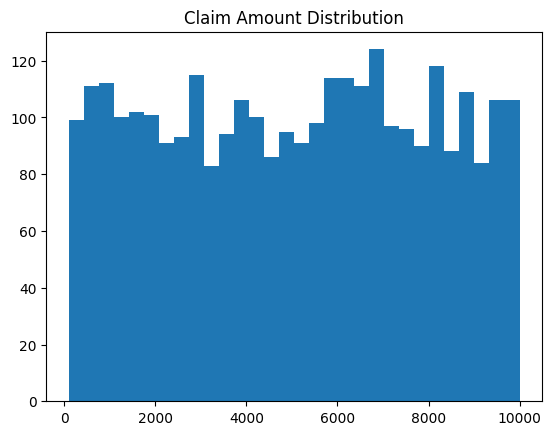

In [42]:
#Claim amount distribution

plt.hist(df["ClaimAmount"], bins=30)
plt.title("Claim Amount Distribution")
plt.show()

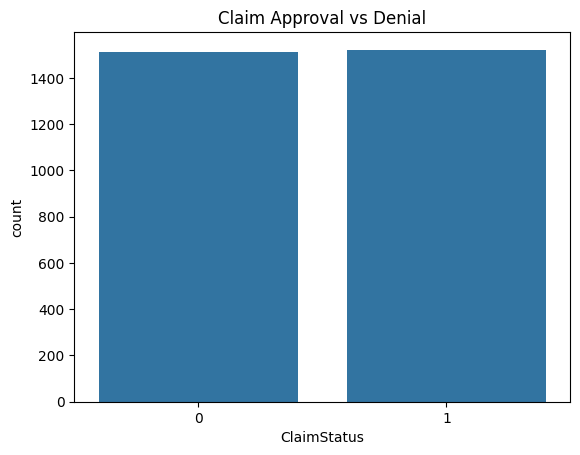

In [43]:
#Claim status distribution

sns.countplot(x="ClaimStatus", data=df)
plt.title("Claim Approval vs Denial")
plt.show()

## Feature Engineering (Date Handling)

Step 6 — Handle Date Column


In [44]:
# Convert to datetime
df["ClaimDate"] = pd.to_datetime(df["ClaimDate"] , dayfirst=True)


In [45]:
# Extract useful features
df["ClaimYear"] = df["ClaimDate"].dt.year
df["ClaimMonth"] = df["ClaimDate"].dt.month

In [46]:
# Drop original date column
df.drop("ClaimDate", axis=1, inplace=True)

df.head()

,ClaimAmount,PatientAge,PatientGender,ProviderSpecialty,ClaimStatus,PatientIncome,PatientMaritalStatus,PatientEmploymentStatus,ClaimType,ClaimSubmissionMethod,ClaimYear,ClaimMonth
1,9512.07,27,M,Pediatrics,1,130448.02,Single,Student,Routine,Online,2023,5
6,675.03,40,M,Neurology,1,44580.09,Divorced,Unemployed,Inpatient,Paper,2024,5
7,8675.14,5,M,Cardiology,1,137118.00,Married,Unemployed,Inpatient,Online,2023,10
8,6051.04,74,F,General Practice,0,107644.30,Divorced,Student,Inpatient,Online,2023,7
9,7109.92,37,M,Neurology,1,102324.96,Single,Retired,Outpatient,Paper,2024,4


## Encoding
Step 7 — Encoding Categorical Features

In [47]:
df = pd.get_dummies(df, drop_first=True)

df.shape

(3034, 22)

## Feature Selection
Step 8 — Feature Selection

In [48]:
X = df.drop("ClaimStatus", axis=1)
y = df["ClaimStatus"]

print(X.shape)
print(y.shape)

(3034, 21)
(3034,)


## Train - Test Split
Step 9 — Train / Test Split

In [49]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(2427, 21)
(607, 21)


## Train Model 
step 10 - Tranning the model

In [50]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=2000)

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,2000
,multi_class,'deprecated'


## Prediction
Step 11 — Prediction

In [51]:
y_pred = model.predict(X_test)

y_pred[:10]

array([1, 1, 0, 0, 1, 1, 1, 0, 1, 0], dtype=int64)

## Evaluation 
step 12 - Evaluating the model


In [52]:

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.49093904448105435


**Step 13 — Advanced Evaluation**

In [53]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[152 147]
 [162 146]]
              precision    recall  f1-score   support

           0       0.48      0.51      0.50       299
           1       0.50      0.47      0.49       308

    accuracy                           0.49       607
   macro avg       0.49      0.49      0.49       607
weighted avg       0.49      0.49      0.49       607



## Model Improvement

The initial Logistic Regression model showed low accuracy (~49%).
To improve performance:
- Applied feature scaling
- Used class_weight='balanced'

**Scaling**

In [54]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Improved model**

In [55]:
# class_weight='balanced'

model = LogisticRegression(max_iter=1000, class_weight='balanced')

model.fit(X_train_scaled, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


## New Accuracy 
Step 15 → New Accuracy

In [56]:
# Predict
y_pred = model.predict(X_test_scaled)

from sklearn.metrics import accuracy_score
print("New Accuracy:", accuracy_score(y_test, y_pred))

New Accuracy: 0.48929159802306427


## New Evaluation
Step 16 → New Evaluation

In [57]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.48      0.51      0.49       299
           1       0.50      0.47      0.49       308

    accuracy                           0.49       607
   macro avg       0.49      0.49      0.49       607
weighted avg       0.49      0.49      0.49       607



##  Step 17 — Feature Improvement 

In [58]:
# Try removing weak / noisy columns

X = df.drop("ClaimStatus", axis=1)
y = df["ClaimStatus"]

## Step 18 — Split Again

In [59]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

## Step 19 — Train Again

In [60]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000)

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

from sklearn.metrics import accuracy_score
print("New Accuracy:", accuracy_score(y_test, y_pred))

New Accuracy: 0.49093904448105435


## Conclusion


## Step 20 — Try Decision Tree

In [61]:
from sklearn.tree import DecisionTreeClassifier

model_dt = DecisionTreeClassifier()

model_dt.fit(X_train, y_train)

y_pred_dt = model_dt.predict(X_test)

from sklearn.metrics import accuracy_score
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 0.5041186161449753


## Final Conclusion

In this project, multiple machine learning models were applied to predict claim approval.

Models Used:
- Logistic Regression
- Decision Tree

Results:
- Logistic Regression Accuracy: ~49%
- Decision Tree Accuracy: ~50%

Key Observations:
- Both models performed close to random guessing
- Indicates weak relationship between input features and target variable (ClaimStatus)

Conclusion:
- The dataset lacks strong predictive features
- Model performance is limited by data quality, not algorithm choice

Future Improvements:
- Collect better quality features
- Perform advanced feature engineering
- Use domain-specific data


In [62]:
import sys
print(sys.executable)

C:\Users\Anike\.conda\envs\ds_env\python.exe
